In [ ]:
# ── Setup: put src/ on the path, then build the analysis dataframe through the
#    configurable merger. All data paths live in src/config.py.
import os, sys
_p = os.getcwd()
while _p != os.path.dirname(_p):
    if os.path.isdir(os.path.join(_p, "src")):
        sys.path.insert(0, os.path.join(_p, "src")); break
    _p = os.path.dirname(_p)

from data_load import load_data_for_modeling, load_and_clean_accident_data
import ruptures as rpt
import os
from typing import Dict, Optional, Tuple, Any
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from analysis_data import build_analysis_dataframe

df_merged = build_analysis_dataframe(level="person")

In [9]:
bins   = [-2,0, 20, 25, 35, 45, 60, 101]
labels = ["Unknown", "0-20", "21-25", "26-35", "36-45", "46-60", "61+"]
df_merged["age_group"] = pd.cut(df_merged["person_age"], bins=bins, labels=labels)


In [11]:
import pandas as pd

# --- hit and run masks ---
mask_solo_bi = df_merged["topic_main_0_3"] == 13   # parked vehicle hit-and-run


solo_bi  = df_merged[mask_solo_bi].groupby(["year", "age_group"], observed=True).size().reset_index(name="count").assign(topic="Solo bicycle fall")

In [16]:
def get_penalty(criterion, n):
    criterion = criterion.lower()
    if criterion == "aic":
        return 2
    elif criterion == "bic":
        return np.log(n)
    elif criterion == "mbic":
        return 3 * np.log(n)


In [17]:
def plot_drunk_driving_trend(df_raw, title="Solo bicycle fall", 
                              figsize=(18, 5), criterion="bic"):
    
    # aggregate to total count per year
    series = (
        df_raw.groupby("year")["count"]
        .sum()
        .sort_index()
    )
    
    n = len(series)
    penalty = get_penalty(criterion, n)
    
    algo = rpt.Pelt(model="rbf").fit(series.values.reshape(-1, 1))
    breakpoints = algo.predict(pen=penalty)[:-1]
    breakpoint_years = [series.index[bp] for bp in breakpoints]
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(series.index, series.values, color="black", marker="o",
            linewidth=1.5, markersize=4)
    
    for year in breakpoint_years:
        ax.axvline(x=year, color="red", linestyle="--", alpha=0.8)
        ax.text(year + 0.3, series.max() * 0.95, str(year), 
                color="red", fontsize=9, ha="left", va="top")
    
    ax.set_title(f"{title} ({criterion.upper()}, {len(breakpoint_years)} changepoint(s))")
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()
    print(f"Changepoint years: {breakpoint_years}")


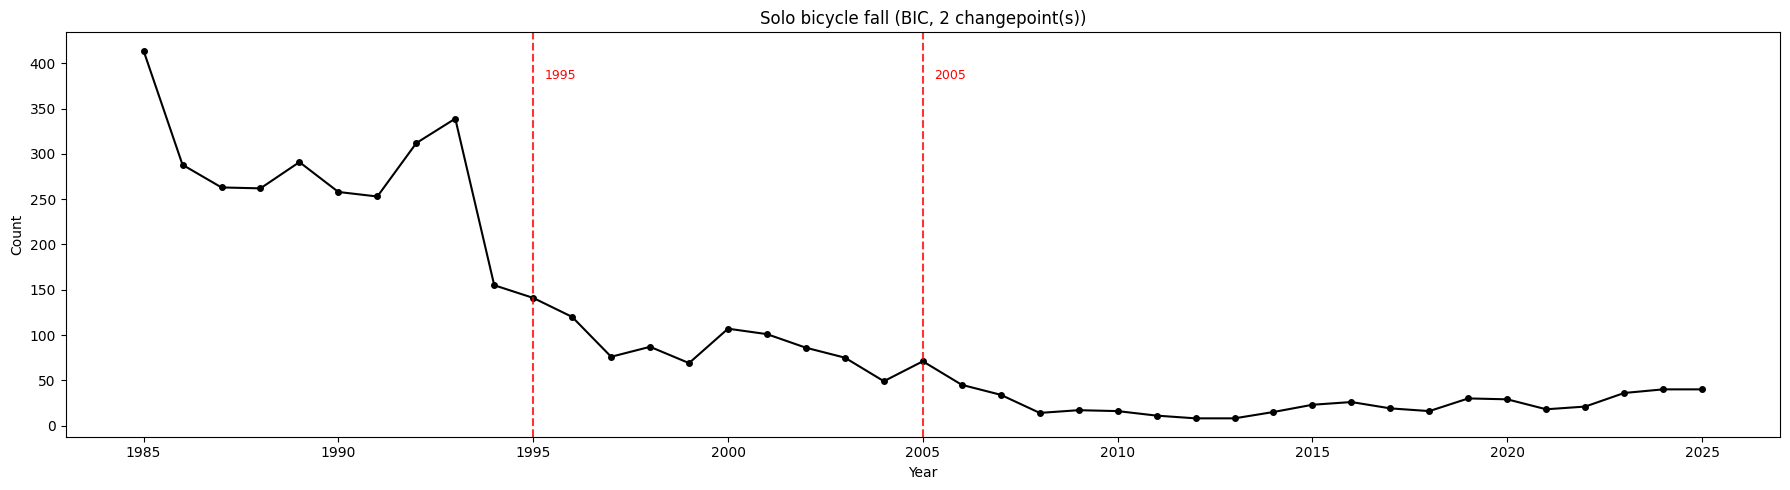

Changepoint years: [1995, 2005]


In [18]:
plot_drunk_driving_trend(solo_bi, criterion="bic")

In [19]:
def plot_by_age(df_raw, title="Solo bicycle fall by age group", 
                               figsize=(18, 6), criterion="bic"):
    df_raw = df_raw.dropna(subset=["count", "year", "age_group"])
    
    # pivot so rows=year, columns=age_group
    counts = df_raw.pivot_table(
        index="year", 
        columns="age_group", 
        values="count", 
        aggfunc="sum",
        fill_value=0
    )
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for age_group in counts.columns:
        series = counts[age_group]
        n = len(series)
        penalty = get_penalty(criterion, n)

        algo = rpt.Pelt(model="rbf").fit(series.values.reshape(-1, 1))
        breakpoints = algo.predict(pen=penalty)[:-1]
        breakpoint_years = [series.index[bp] for bp in breakpoints]
        print(f"Age group {age_group} - breakpoints: {breakpoint_years}")
        ax.plot(series.index, series.values, marker="o", linewidth=1.5, 
                markersize=4, label=age_group)

        for year in breakpoint_years:
            ax.axvline(x=year, color="red", linestyle="--", alpha=0.5)
            ax.text(year + 0.3, series.max(), str(year), color="red",
                    fontsize=8, ha="left", va="top")

    ax.set_title(f"{title} ({criterion.upper()})")
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
    ax.legend(title="Age group", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

Age group Unknown - breakpoints: [2000]
Age group 0-20 - breakpoints: [1995, 2005]
Age group 21-25 - breakpoints: [1995]
Age group 26-35 - breakpoints: [1995]
Age group 36-45 - breakpoints: [1995, 2005]
Age group 46-60 - breakpoints: [1995]
Age group 61+ - breakpoints: [1995]


/tmp/ipykernel_479216/244974199.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts = df_raw.pivot_table(


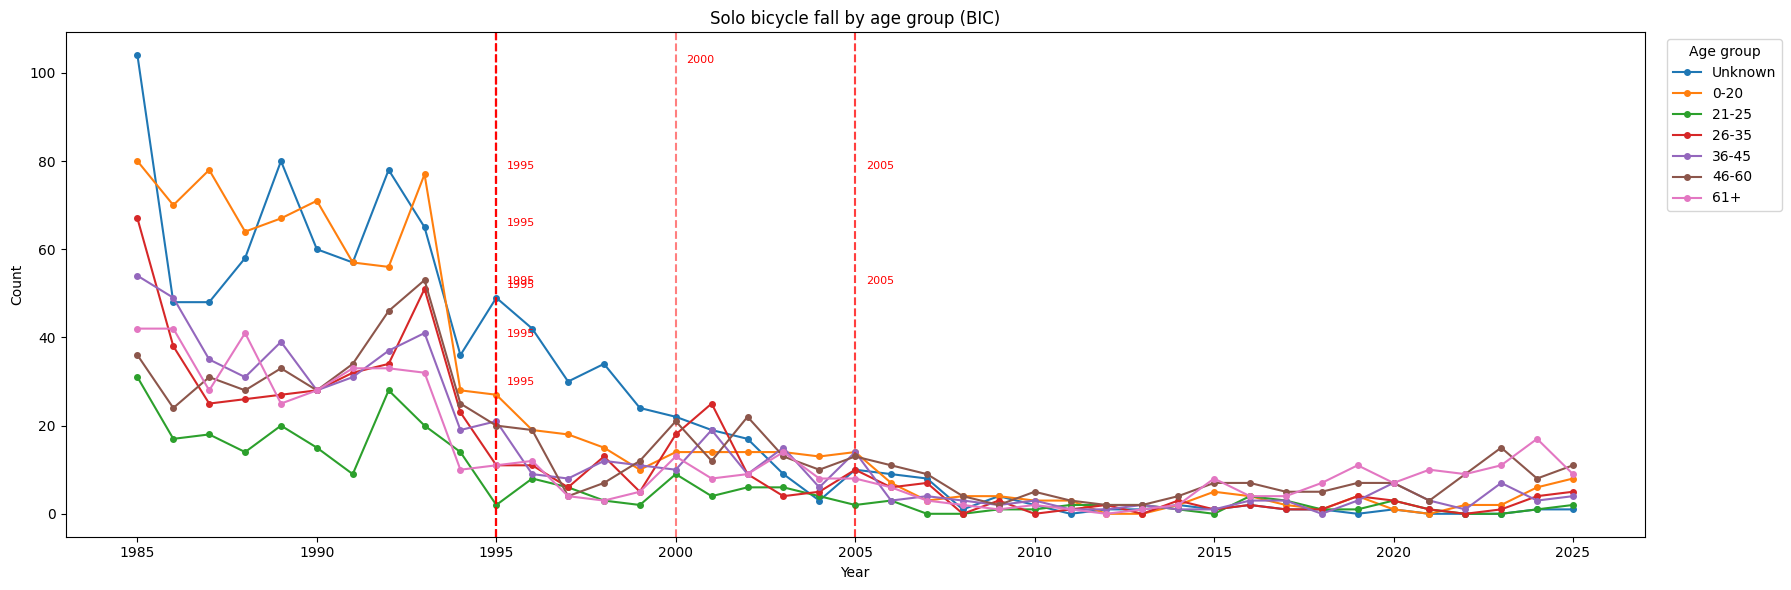

In [23]:
plot_by_age(solo_bi, criterion="bic")